**Imports**

In [1]:
from src.data.load_dataset import load_paired_data, load_data
from src.modules.super_resolution import SuperResolutionModel
import numpy as np
import torch
import matplotlib.pyplot as plt
import gc

**Cuda**

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

if device.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.cuda.synchronize()
    before_alloc = torch.cuda.memory_allocated(device) / 1024**2
    before_reserved = torch.cuda.memory_reserved(device) / 1024**2
    print(f"Before reset - allocated: {before_alloc:.2f} MB, reserved/cached: {before_reserved:.2f} MB")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()

    after_alloc = torch.cuda.memory_allocated(device) / 1024**2
    after_reserved = torch.cuda.memory_reserved(device) / 1024**2
    print(f"After reset  - allocated: {after_alloc:.2f} MB, reserved/cached: {after_reserved:.2f} MB")
else:
    gc.collect()
    print("No CUDA device detected — performed Python garbage collection.")

Device: cuda
PyTorch version: 2.9.0+cu130
Before reset - allocated: 0.00 MB, reserved/cached: 0.00 MB
After reset  - allocated: 0.00 MB, reserved/cached: 0.00 MB


c:\Users\Filip\Documents\studia-local\Unsupervised-learning---images\venv\Lib\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


**Load Dataset**

In [3]:
train_loader_small, test_loader_small, val_loader_small = load_paired_data()


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

**Super Resolution**

In [4]:
FORCE_LEARNING = True
LOAD_BEST = False

sr_model = SuperResolutionModel(
    learning_rate=0.001,
    load_best=LOAD_BEST  
) 


if not sr_model.model_loaded or FORCE_LEARNING:
    history = sr_model.fit(
        train_loader=train_loader_small, 
        val_loader=val_loader_small,     
        epochs=100
    )

Start treningu SR (x2) | AMP: True


Epoch 1/100 [Val]: 100%|██████████| 191/191 [00:25<00:00,  7.63it/s]


 -> Train Loss: 0.01379 | Val Loss: 0.01307
-> Zapisano model SR: checkpoints\best_super_resolution.pt (Loss: 0.01307)


Epoch 2/100 [Val]: 100%|██████████| 191/191 [00:24<00:00,  7.71it/s]


 -> Train Loss: 0.01317 | Val Loss: 0.01283
-> Zapisano model SR: checkpoints\best_super_resolution.pt (Loss: 0.01283)


...

 -> Train Loss: 0.01194 | Val Loss: 0.01172


Epoch 39/100 [Val]: 100%|██████████| 191/191 [00:24<00:00,  7.91it/s]


 -> Train Loss: 0.01189 | Val Loss: 0.01171


Epoch 40/100 [Val]: 100%|██████████| 191/191 [00:24<00:00,  7.84it/s]

 -> Train Loss: 0.01191 | Val Loss: 0.01177
Early stopping triggered at epoch 40


**Load test Datasets**

In [5]:
train_loader, test_loader, val_loader = load_data(add_fourth_channel=True)

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

**Wyniki 256 -> 512 -> 1024**

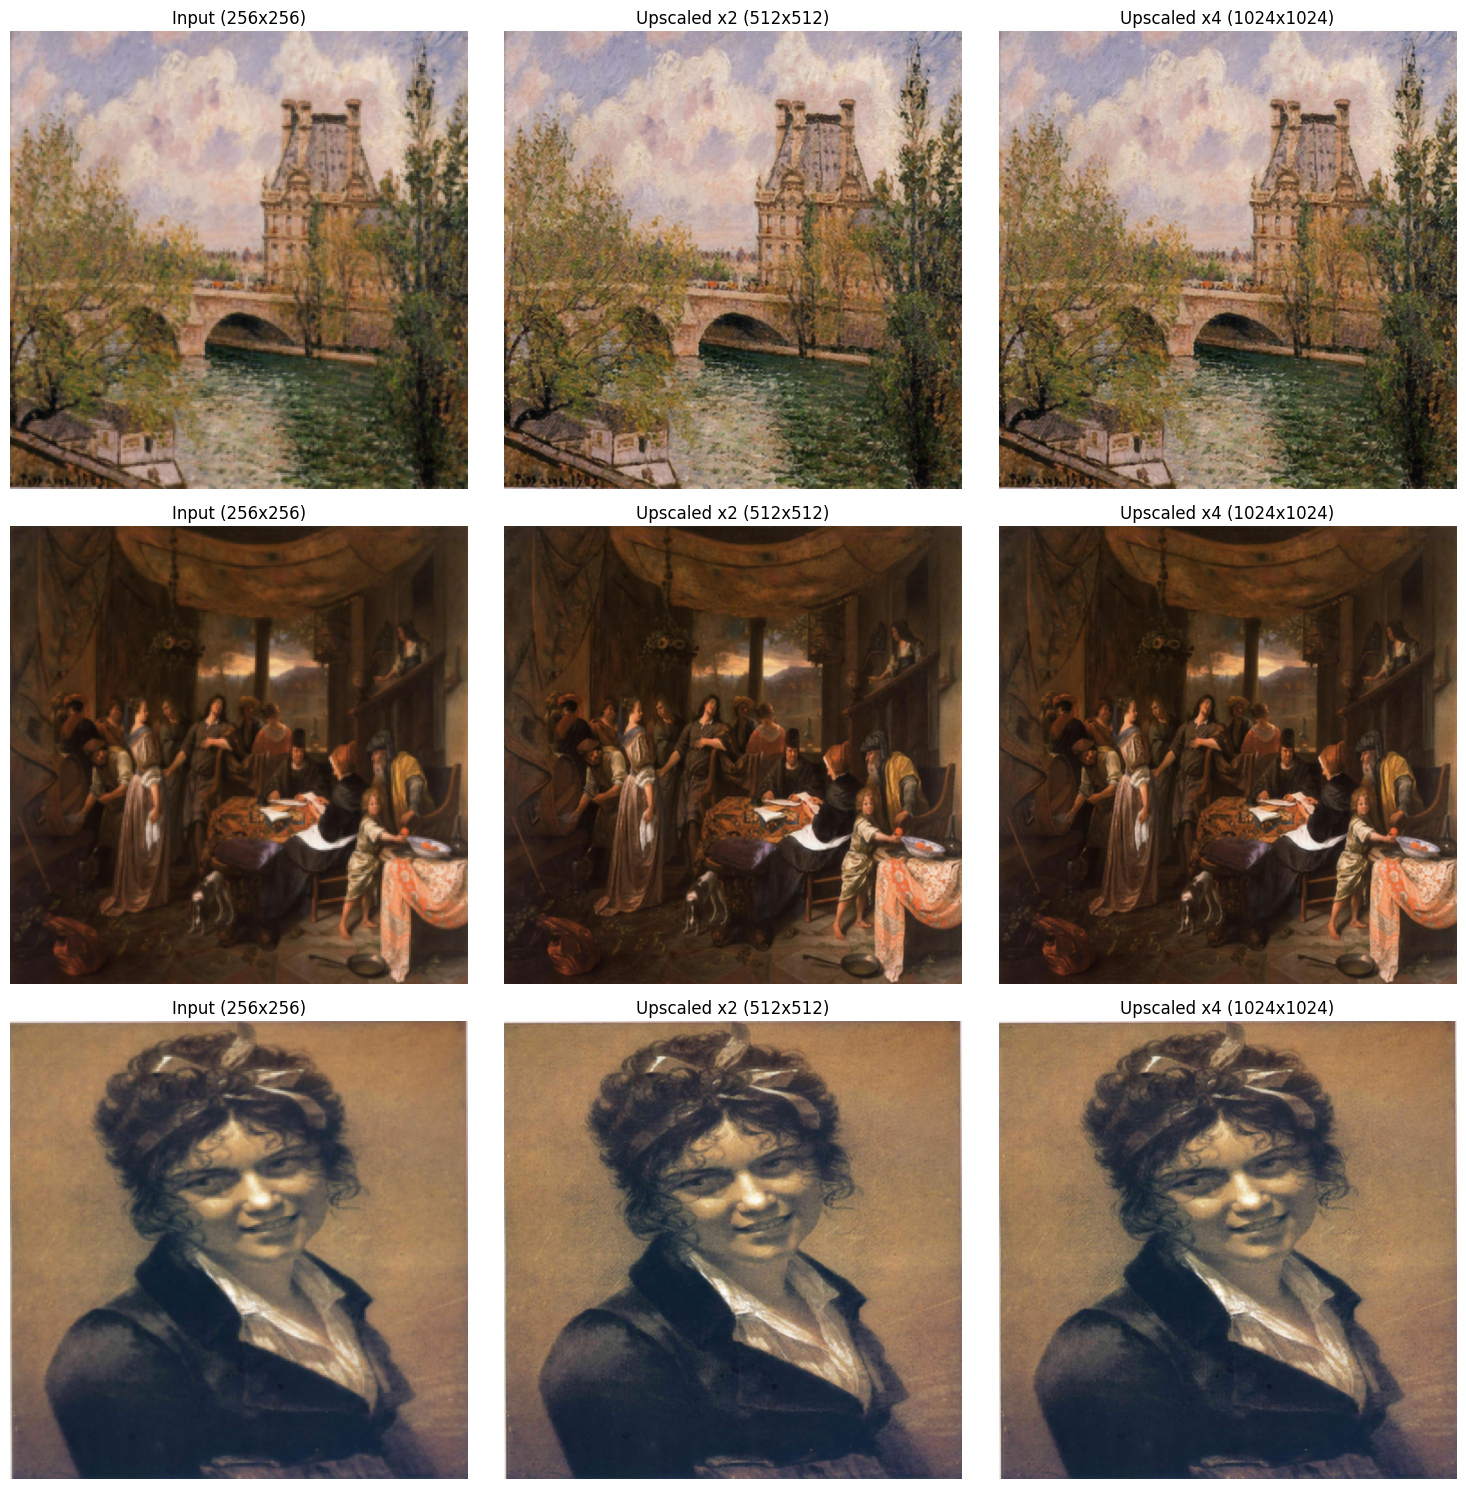

In [7]:
def show_sr_results(model, dataloader, num_samples=3):
    model.eval()
    device = model.device
    
    batch = next(iter(dataloader))
    if isinstance(batch, (list, tuple)):
        lr_imgs = batch[0]
    else:
        lr_imgs = batch
    
    indices = torch.randperm(len(lr_imgs))[:num_samples]
    
    _, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_256 = lr_imgs[idx].unsqueeze(0).to(device)
            
            if img_256.shape[1] == 4 and getattr(model, 'input_channels', 3) == 3:
                img_256 = img_256[:, :3, :, :]
            
            img_512 = model(img_256)
            img_1024 = model(img_512)
            imgs = [img_256, img_512, img_1024]
            titles = [f"Input ({img_256.shape[-2]}x{img_256.shape[-1]})", 
                      f"Upscaled x2 ({img_512.shape[-2]}x{img_512.shape[-1]})", 
                      f"Upscaled x4 ({img_1024.shape[-2]}x{img_1024.shape[-1]})"]
            
            for j, img_tensor in enumerate(imgs):
                img_np = img_tensor.squeeze().cpu().permute(1, 2, 0).clamp(0, 1).numpy()
                
                ax = axes[i, j]
                ax.imshow(img_np)
                ax.set_title(titles[j])
                ax.axis('off')

    plt.tight_layout()
    plt.show()

show_sr_results(sr_model, test_loader, num_samples=3)

**Historia uczenia**

PODSUMOWANIE TRENINGU

Liczba epok: 40

Najlepsza Train Loss: 0.011874
Najlepsza Val Loss: 0.011595

Ostatnia Train Loss: 0.011907
Ostatnia Val Loss: 0.011771

Poprawa Train Loss: 13.69%
Poprawa Val Loss: 9.95%


KeyError: 'train_recon_loss'

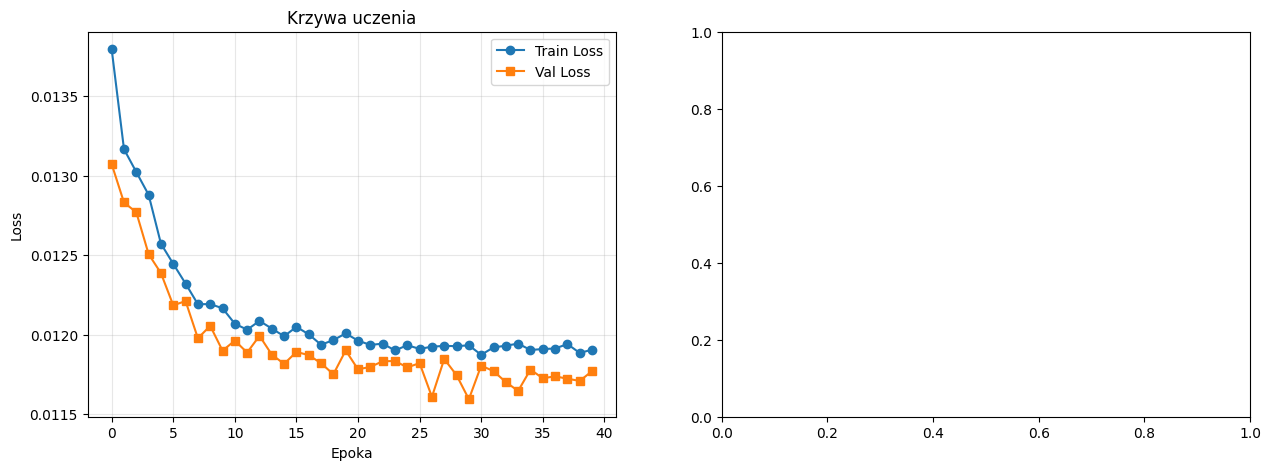

In [8]:
print("=" * 60)
print("PODSUMOWANIE TRENINGU")
print("=" * 60)

print(f"\nLiczba epok: {len(history['train_loss'])}")
print(f"\nNajlepsza Train Loss: {min(history['train_loss']):.6f}")
print(f"Najlepsza Val Loss: {min(history['val_loss']):.6f}")
print(f"\nOstatnia Train Loss: {history['train_loss'][-1]:.6f}")
print(f"Ostatnia Val Loss: {history['val_loss'][-1]:.6f}")

train_improvement = ((history['train_loss'][0] - history['train_loss'][-1]) / history['train_loss'][0]) * 100
val_improvement = ((history['val_loss'][0] - history['val_loss'][-1]) / history['val_loss'][0]) * 100

print(f"\nPoprawa Train Loss: {train_improvement:.2f}%")
print(f"Poprawa Val Loss: {val_improvement:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].set_title('Krzywa uczenia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

epochs = np.arange(1, len(history['train_loss']) + 1)
axes[1].plot(epochs, history['train_recon_loss'], label='Train Recon Loss', marker='o')
axes[1].plot(epochs, history['val_recon_loss'], label='Val Recon Loss', marker='s')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Strata rekonstrukcji')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()